# h1_v1_allow vs h1_v2_allow Compare EDA

`data_h1_v1_allow`와 `data_h1_v2_allow`를 함께 비교하는 EDA입니다.

핵심 목적은 다음입니다.
1. v2가 v1 대비 feature 품질이나 분포에서 얼마나 달라졌는지 본다.
2. 두 데이터셋의 outlier 후보 성향이 얼마나 다른지 본다.
3. 같은 `trial_id`가 양쪽에 존재한다면, 추출 결과가 실제로 얼마나 달라졌는지 paired 비교로 본다.

In [16]:
import json
import platform
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

In [17]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1400)

system = platform.system()
if system == "Darwin":
    font_candidates = ["Nanum Gothic", "AppleGothic"]
elif system == "Windows":
    font_candidates = ["Malgun Gothic"]
else:
    font_candidates = ["Nanum Gothic", "DejaVu Sans"]

for font_name in font_candidates:
    try:
        plt.rcParams["font.family"] = font_name
        print(f"한글 폰트 적용: {font_name}")
        break
    except Exception:
        continue

plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", context="notebook")

한글 폰트 적용: Malgun Gothic


## 1. 데이터 로드

In [18]:
ROOT = Path.cwd()
if ROOT.name != "EDA":
    raise RuntimeError("작업 디렉토리를 services/ai/train/EDA 로 맞춘 뒤 실행하세요.")

V1_DIR = ROOT.parent.parent / "data" / "data_h1_v1_allow"
V2_DIR = ROOT.parent.parent / "data" / "data_h1_v2_allow"
FEATURE_CONFIG_PATH = ROOT.parent.parent / "configs" / "feature_config.yaml"

print("ROOT:", ROOT)
print("V1_DIR:", V1_DIR)
print("V2_DIR:", V2_DIR)

for path in [V1_DIR, V2_DIR, FEATURE_CONFIG_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

ROOT: c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\EDA
V1_DIR: c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow
V2_DIR: c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow


In [19]:
with open(FEATURE_CONFIG_PATH, "r", encoding="utf-8") as f:
    feature_config = yaml.safe_load(f)

FEATURE_GROUPS = feature_config["groups"]
FEATURE_NAME_KR = feature_config.get("names_ko", {})
EXCLUDE_COL = set(feature_config.get("exclude", [])) | {"trial_id", "label", "path", "dataset"}
FEATURE_GROUP_MAP = {
    feature: group
    for group, features in FEATURE_GROUPS.items()
    for feature in features
}


def load_allow_trials(data_dir: Path, dataset_name: str) -> pd.DataFrame:
    rows = []
    for path in sorted(data_dir.glob("trial_*.json")):
        payload = json.loads(path.read_text(encoding="utf-8"))
        trial_id = payload.get("trialID") or payload.get("trialId") or payload.get("trial_id")
        feature_values = payload.get("features") or payload.get("metrics") or {}
        row = {
            "dataset": dataset_name,
            "trial_id": int(trial_id),
            "label": payload.get("label"),
            "path": str(path),
        }
        if isinstance(feature_values, dict):
            row.update(feature_values)
        rows.append(row)
    return pd.DataFrame(rows).sort_values("trial_id").reset_index(drop=True)

v1_df = load_allow_trials(V1_DIR, "h1_v1_allow")
v2_df = load_allow_trials(V2_DIR, "h1_v2_allow")
all_df = pd.concat([v1_df, v2_df], ignore_index=True)

print("v1 shape:", v1_df.shape)
print("v2 shape:", v2_df.shape)
display(pd.DataFrame([
    {"dataset": "h1_v1_allow", "trial_count": len(v1_df), "min_trial_id": v1_df['trial_id'].min(), "max_trial_id": v1_df['trial_id'].max()},
    {"dataset": "h1_v2_allow", "trial_count": len(v2_df), "min_trial_id": v2_df['trial_id'].min(), "max_trial_id": v2_df['trial_id'].max()},
]))

v1 shape: (720, 38)
v2 shape: (30, 38)


,dataset,trial_count,min_trial_id,max_trial_id
0,h1_v1_allow,720,1,750
1,h1_v2_allow,30,690,719


## 2. 데이터 전처리

In [20]:
meta_cols = [c for c in ["dataset", "trial_id", "label", "path"] if c in all_df.columns]
feature_cols = [c for c in all_df.columns if c not in meta_cols and c not in EXCLUDE_COL]

for frame in [v1_df, v2_df, all_df]:
    for col in feature_cols:
        frame[col] = pd.to_numeric(frame[col], errors="coerce")

shared_feature_cols = [c for c in feature_cols if c in v1_df.columns and c in v2_df.columns]
print("공통 feature 수:", len(shared_feature_cols))
print(shared_feature_cols)

공통 feature 수: 34
['reclick_rate', 'misclick_rate', 'mouse_jerk_mean', 'double_click_rate', 'mouse_overshoot_flag', 'mousemove_event_rate', 'pre_click_scroll_flag', 'time_to_first_click_ms', 'inter_click_interval_ms', 'mouse_acceleration_mean', 'mouse_speed_change_mean', 'pre_click_hover_time_ms', 'click_offset_variance_px', 'mouse_stop_segment_count', 'mouse_avg_speed_px_per_ms', 'mouse_hover_dwell_time_ms', 'mouse_max_speed_px_per_ms', 'mouse_path_curvature_mean', 'pre_click_mousemove_count', 'click_position_repeat_rate', 'mouse_direction_change_count', 'mouse_path_straightness_score', 'edge_or_fixed_point_visit_rate', 'mouse_total_travel_distance_px', 'click_sequence_consistency_score', 'immediate_post_render_click_rate', 'pre_click_path_300ms_straightness', 'pre_click_path_500ms_straightness', 'inter_element_move_interval_std_ms', 'click_offset_from_element_center_px', 'time_from_element_visible_to_click_ms', 'pre_click_path_300ms_total_distance_px', 'pre_click_path_500ms_total_dist

In [21]:
def feature_quality_summary(frame: pd.DataFrame, dataset_name: str, feature_cols: list[str]) -> pd.DataFrame:
    rows = []
    for feature in feature_cols:
        s = pd.to_numeric(frame[feature], errors="coerce")
        valid = s.dropna()
        q25 = valid.quantile(0.25) if len(valid) else np.nan
        q50 = valid.quantile(0.50) if len(valid) else np.nan
        q75 = valid.quantile(0.75) if len(valid) else np.nan
        iqr = q75 - q25 if pd.notna(q75) and pd.notna(q25) else np.nan
        rows.append({
            "dataset": dataset_name,
            "group": FEATURE_GROUP_MAP.get(feature, "other"),
            "feature": feature,
            "feature_ko": FEATURE_NAME_KR.get(feature, feature),
            "count": int(valid.shape[0]),
            "null_ratio": float(s.isna().mean()),
            "zero_ratio": float((valid == 0).mean()) if len(valid) else np.nan,
            "n_unique": int(valid.nunique()) if len(valid) else 0,
            "mean": float(valid.mean()) if len(valid) else np.nan,
            "std": float(valid.std()) if len(valid) else np.nan,
            "median": float(q50) if pd.notna(q50) else np.nan,
            "iqr": float(iqr) if pd.notna(iqr) else np.nan,
            "min": float(valid.min()) if len(valid) else np.nan,
            "max": float(valid.max()) if len(valid) else np.nan,
            "skew": float(valid.skew()) if len(valid) > 2 else np.nan,
        })
    return pd.DataFrame(rows)


def robust_zscore(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    median = s.median()
    mad = (s - median).abs().median()
    scale = mad * 1.4826
    if pd.isna(scale) or scale <= 1e-12:
        return pd.Series(np.nan, index=s.index)
    return (s - median) / scale


def iqr_bounds(series: pd.Series) -> tuple[float, float]:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return (np.nan, np.nan)
    q25 = s.quantile(0.25)
    q75 = s.quantile(0.75)
    iqr = q75 - q25
    return (q25 - 1.5 * iqr, q75 + 1.5 * iqr)


def compute_trial_scores(frame: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    trial_scores = frame[["dataset", "trial_id", "path"]].copy()
    robust_flag_cols = []
    iqr_flag_cols = []
    extreme_flag_cols = []

    for feature in feature_cols:
        s = pd.to_numeric(frame[feature], errors="coerce")
        robust_flag_cols.append((robust_zscore(s).abs() >= 3.5).rename(feature))
        lower, upper = iqr_bounds(s)
        iqr_flag_cols.append((((s < lower) | (s > upper)).fillna(False)).rename(feature))
        valid = s.dropna()
        if len(valid):
            low_q = valid.quantile(0.01)
            high_q = valid.quantile(0.99)
            extreme = ((s <= low_q) | (s >= high_q)).fillna(False)
        else:
            extreme = pd.Series(False, index=s.index)
        extreme_flag_cols.append(extreme.rename(feature))

    robust_flag_df = pd.concat(robust_flag_cols, axis=1).fillna(False)
    iqr_flag_df = pd.concat(iqr_flag_cols, axis=1).fillna(False)
    extreme_flag_df = pd.concat(extreme_flag_cols, axis=1).fillna(False)

    trial_scores["robust_outlier_count"] = robust_flag_df.sum(axis=1)
    trial_scores["iqr_outlier_count"] = iqr_flag_df.sum(axis=1)
    trial_scores["extreme_1pct_count"] = extreme_flag_df.sum(axis=1)

    iforest_features = [c for c in feature_cols if frame[c].notna().sum() > 0 and frame[c].nunique(dropna=True) > 1]
    iforest_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("iforest", IsolationForest(n_estimators=300, contamination="auto", max_features=1.0, random_state=42)),
    ])
    iforest_pipe.fit(frame[iforest_features])
    raw_decision = pd.Series(iforest_pipe.decision_function(frame[iforest_features]), index=frame.index)
    trial_scores["iforest_outlier_score"] = (-raw_decision).rank(pct=True)

    for col in ["robust_outlier_count", "iqr_outlier_count", "extreme_1pct_count"]:
        trial_scores[f"{col}_rank"] = trial_scores[col].rank(method="average", pct=True)

    trial_scores["composite_score"] = trial_scores[[
        "robust_outlier_count_rank",
        "iqr_outlier_count_rank",
        "extreme_1pct_count_rank",
        "iforest_outlier_score",
    ]].mean(axis=1)
    return trial_scores.sort_values("composite_score", ascending=False).reset_index(drop=True)

## 3. 기본 분석

### 3-1 데이터 품질 비교

In [22]:
v1_summary = feature_quality_summary(v1_df, "h1_v1_allow", shared_feature_cols)
v2_summary = feature_quality_summary(v2_df, "h1_v2_allow", shared_feature_cols)

compare_quality_df = v1_summary.merge(
    v2_summary,
    on=["feature", "feature_ko", "group"],
    suffixes=("_v1", "_v2"),
)
compare_quality_df["null_ratio_gap"] = compare_quality_df["null_ratio_v2"] - compare_quality_df["null_ratio_v1"]
compare_quality_df["zero_ratio_gap"] = compare_quality_df["zero_ratio_v2"] - compare_quality_df["zero_ratio_v1"]
compare_quality_df["count_gap"] = compare_quality_df["count_v2"] - compare_quality_df["count_v1"]

print("null / zero ratio 차이가 큰 feature")
display(compare_quality_df[[
    "group", "feature", "null_ratio_v1", "null_ratio_v2", "null_ratio_gap", "zero_ratio_v1", "zero_ratio_v2", "zero_ratio_gap", "count_v1", "count_v2"
]].sort_values(["null_ratio_gap", "zero_ratio_gap"], key=lambda s: s.abs(), ascending=False))

null / zero ratio 차이가 큰 feature


,group,feature,null_ratio_v1,null_ratio_v2,null_ratio_gap,zero_ratio_v1,zero_ratio_v2,zero_ratio_gap,count_v1,count_v2
29,other,click_offset_from_element_center_px,1.000000,0.000000,-1.000000,NaN,0.000000,NaN,0,30
30,click,time_from_element_visible_to_click_ms,1.000000,0.000000,-1.000000,NaN,0.000000,NaN,0,30
33,click,time_from_element_clickable_to_click_ms,1.000000,0.000000,-1.000000,NaN,0.000000,NaN,0,30
25,click,immediate_post_render_click_rate,0.998611,0.000000,-0.998611,1.000000,1.000000,0.000000,1,30
15,mouse,mouse_hover_dwell_time_ms,0.998611,0.066667,-0.931944,0.000000,0.000000,0.000000,1,28
12,other,click_offset_variance_px,1.000000,0.400000,-0.600000,NaN,0.000000,NaN,0,18
28,other,inter_element_move_interval_std_ms,1.000000,0.400000,-0.600000,NaN,0.000000,NaN,0,18
24,click,click_sequence_consistency_score,0.295833,0.000000,-0.295833,1.000000,0.500000,-0.500000,507,30
19,click,click_position_repeat_rate,0.295833,0.000000,-0.295833,0.903353,1.000000,0.096647,507,30
2,mouse,mouse_jerk_mean,0.055556,0.133333,0.077778,0.000000,0.000000,0.000000,680,26


### 3-2 분포 shift 비교

In [23]:
shift_df = compare_quality_df.copy()
shift_df["mean_diff"] = shift_df["mean_v2"] - shift_df["mean_v1"]
shift_df["median_diff"] = shift_df["median_v2"] - shift_df["median_v1"]
shift_df["pooled_std"] = np.sqrt((shift_df["std_v1"] ** 2 + shift_df["std_v2"] ** 2) / 2)
shift_df["smd"] = shift_df["mean_diff"] / shift_df["pooled_std"]
shift_df["abs_smd"] = shift_df["smd"].abs()
shift_df["iqr_ratio"] = shift_df["iqr_v2"] / shift_df["iqr_v1"]

print("분포 차이가 큰 feature (abs SMD 순)")
display(shift_df[[
    "group", "feature", "mean_v1", "mean_v2", "median_v1", "median_v2", "std_v1", "std_v2", "abs_smd", "iqr_v1", "iqr_v2", "iqr_ratio"
]].sort_values("abs_smd", ascending=False))

분포 차이가 큰 feature (abs SMD 순)


,group,feature,mean_v1,mean_v2,median_v1,median_v2,std_v1,std_v2,abs_smd,iqr_v1,iqr_v2,iqr_ratio
24,click,click_sequence_consistency_score,0.000000,0.280000,0.000000,0.083333,0.000000e+00,0.353158,1.121255,0.000000,0.500000,inf
4,mouse,mouse_overshoot_flag,0.000000,0.200000,0.000000,0.000000,0.000000e+00,0.406838,0.695222,0.000000,0.000000,NaN
1,click,misclick_rate,0.000000,0.054762,0.000000,0.000000,0.000000e+00,0.117835,0.657235,0.000000,0.000000,NaN
3,click,double_click_rate,0.145161,0.042381,0.000000,0.000000,2.080324e-01,0.099701,0.630079,0.333333,0.000000,0.000000
20,mouse,mouse_direction_change_count,15.417847,20.464286,14.000000,23.500000,1.139502e+01,12.173079,0.428010,17.000000,18.000000,1.058824
19,click,click_position_repeat_rate,0.018630,0.000000,0.000000,0.000000,6.836198e-02,0.000000,0.385400,0.000000,0.000000,NaN
27,mouse,pre_click_path_500ms_straightness,0.726361,0.610333,0.950000,0.825000,3.797977e-01,0.418820,0.290225,0.412500,0.865000,2.096970
32,mouse,pre_click_path_500ms_total_distance_px,146.927778,108.333333,99.000000,109.000000,1.882916e+02,111.521247,0.249410,171.250000,128.750000,0.751825
31,mouse,pre_click_path_300ms_total_distance_px,42.869444,29.966667,21.000000,19.500000,6.922969e+01,32.651222,0.238392,66.000000,46.250000,0.700758
5,mouse,mousemove_event_rate,7.308533,8.228153,7.505759,8.876324,4.013111e+00,3.947937,0.231022,5.009858,3.527215,0.704055


overlay 확인 우선 feature:
['click_sequence_consistency_score', 'mouse_overshoot_flag', 'misclick_rate', 'double_click_rate', 'mouse_direction_change_count', 'click_position_repeat_rate', 'pre_click_path_500ms_straightness', 'pre_click_path_500ms_total_distance_px', 'pre_click_path_300ms_total_distance_px', 'mousemove_event_rate', 'mouse_stop_segment_count', 'pre_click_hover_time_ms']


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25712\4181517161.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(s1, ax=ax, label="v1", color="#3182bd")
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25712\4181517161.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(s1, ax=ax, label="v1", color="#3182bd")
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25712\4181517161.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(s1, ax=ax, label="v1", color="#3182bd")
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25712\4181517161.py:16: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(s2, ax=ax, label="v2", color="#e6550d")
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_2571

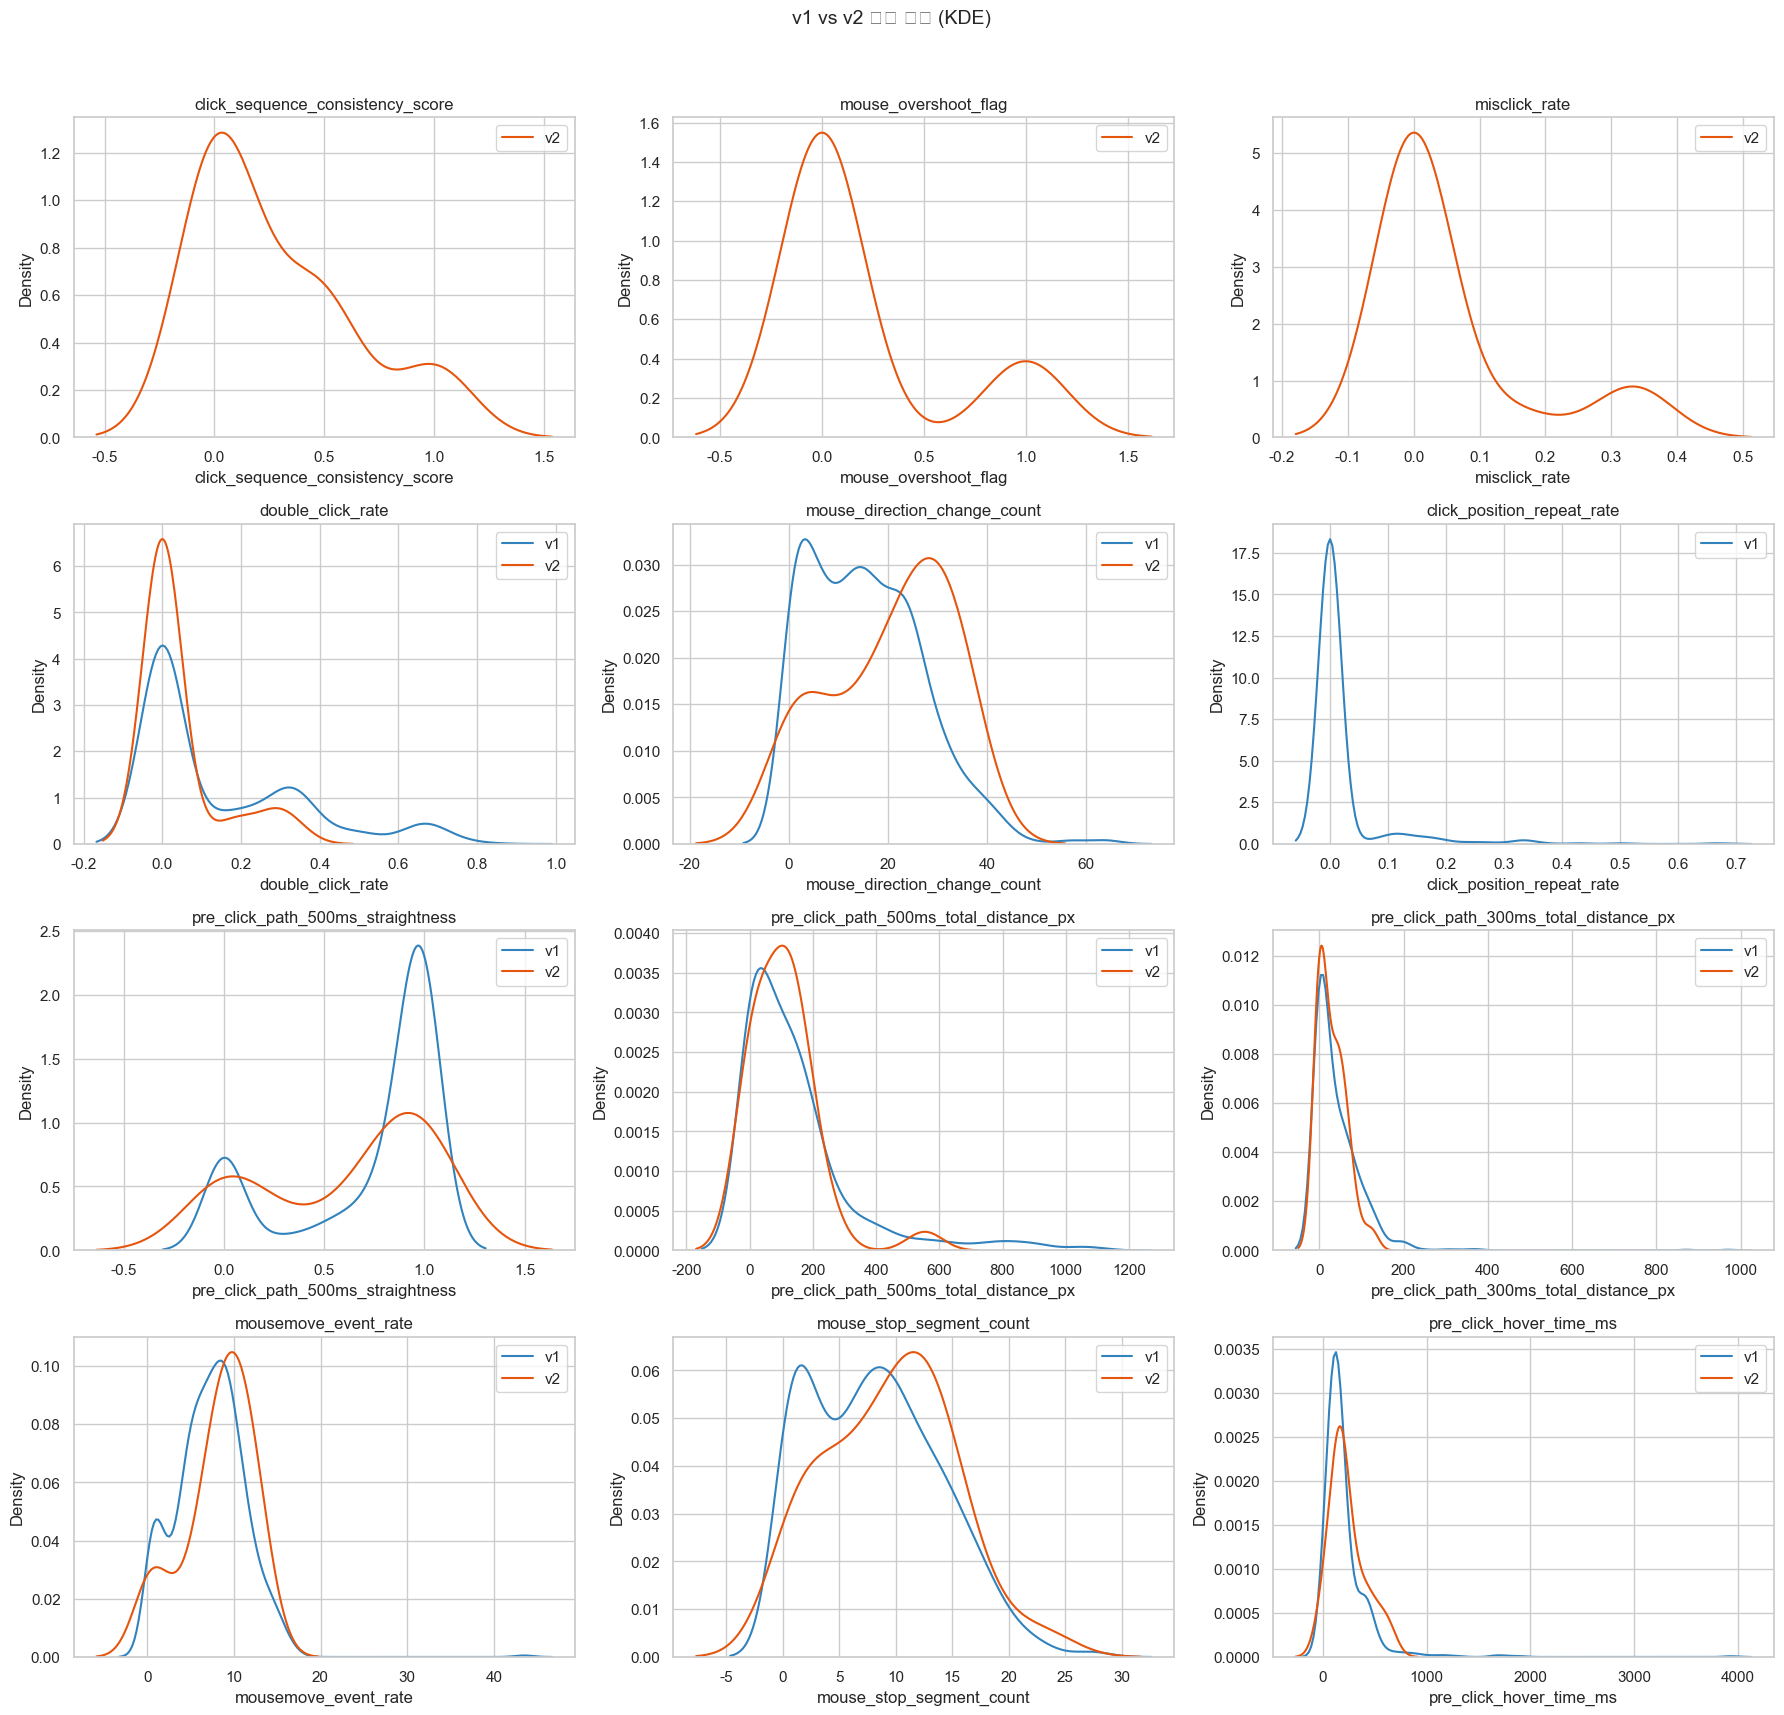

In [24]:
top_shift_features = shift_df.sort_values("abs_smd", ascending=False)["feature"].head(12).tolist()
print("overlay 확인 우선 feature:")
print(top_shift_features)

ncols = 3
nrows = int(np.ceil(len(top_shift_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows))
axes = np.array(axes).reshape(-1)

for ax, feature in zip(axes, top_shift_features):
    s1 = v1_df[feature].dropna()
    s2 = v2_df[feature].dropna()
    if len(s1):
        sns.kdeplot(s1, ax=ax, label="v1", color="#3182bd")
    if len(s2):
        sns.kdeplot(s2, ax=ax, label="v2", color="#e6550d")
    ax.set_title(feature)
    ax.legend()

for ax in axes[len(top_shift_features):]:
    ax.axis("off")

fig.suptitle("v1 vs v2 분포 비교 (KDE)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 3-3 상관관계 / PCA 비교

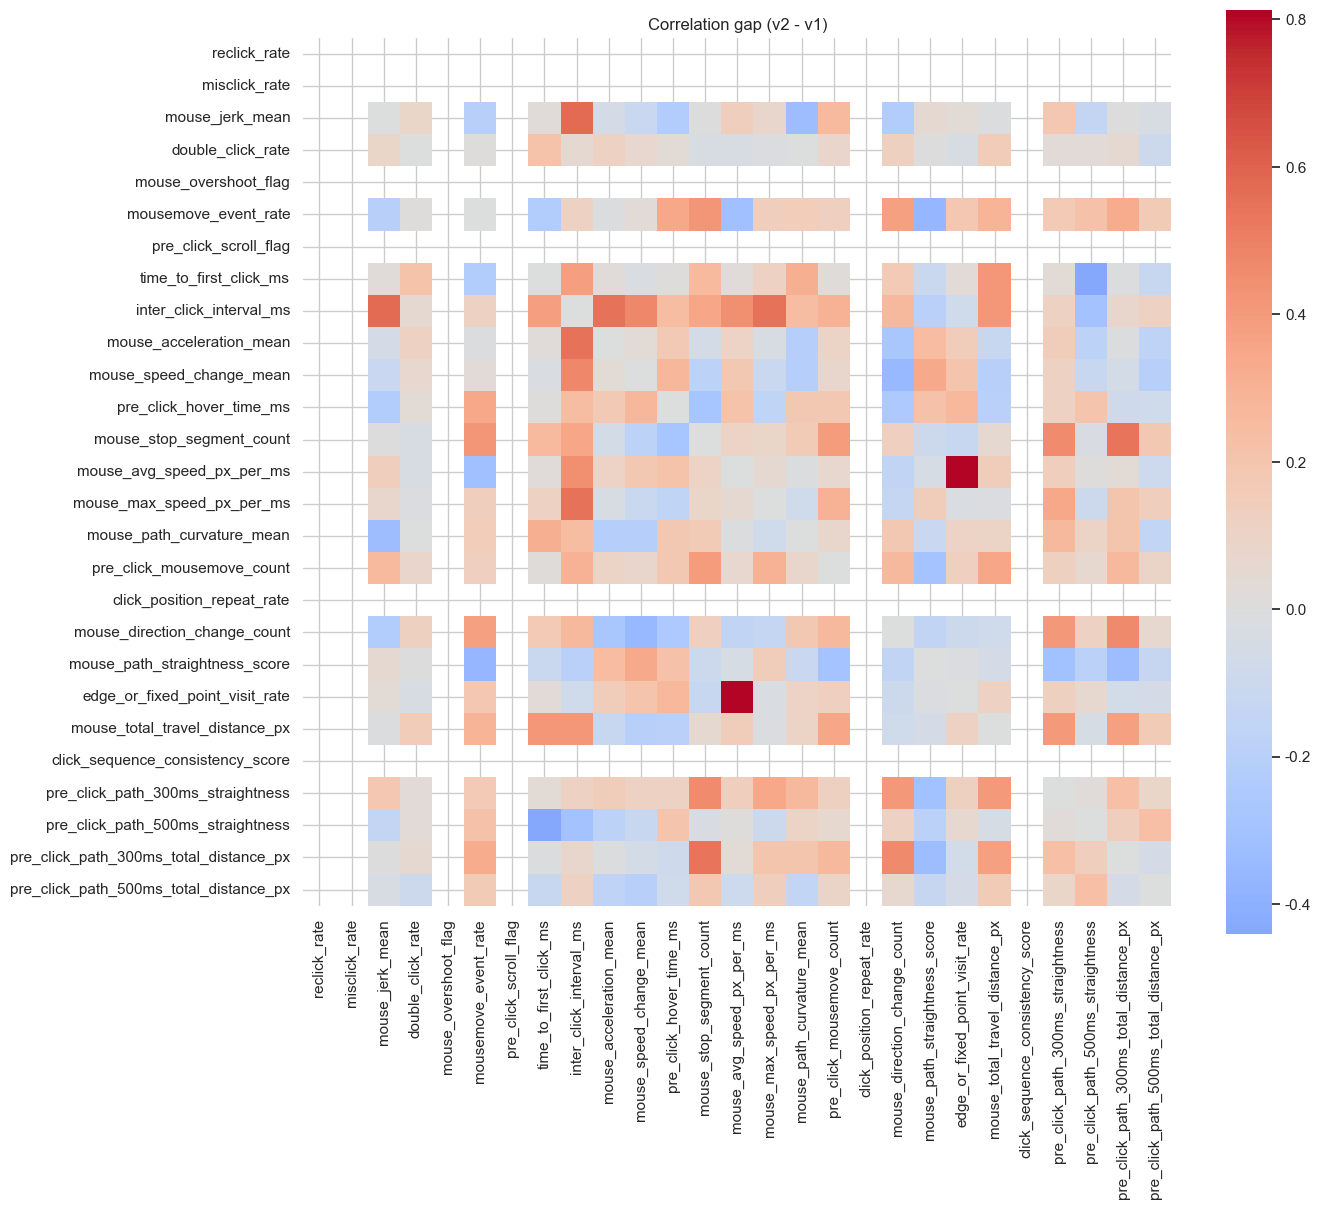

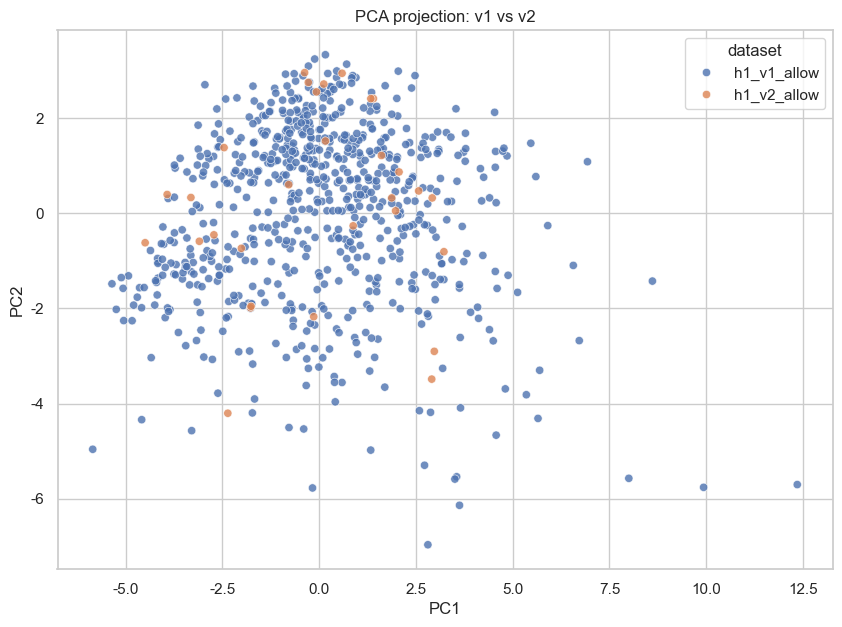

In [25]:
corr_features = shift_df.loc[
    (shift_df["null_ratio_v1"] < 0.50) & (shift_df["null_ratio_v2"] < 0.50) & (shift_df["count_v2"] >= 10),
    "feature",
].tolist()

v1_corr = v1_df[corr_features].corr()
v2_corr = v2_df[corr_features].corr()
corr_gap = v2_corr - v1_corr

plt.figure(figsize=(14, 12))
sns.heatmap(corr_gap, cmap="coolwarm", center=0, square=True)
plt.title("Correlation gap (v2 - v1)")
plt.show()

pca_features = shift_df.loc[
    (shift_df["null_ratio_v1"] < 0.80) & (shift_df["null_ratio_v2"] < 0.80),
    "feature",
].tolist()

combined_for_pca = all_df[["dataset", "trial_id"] + pca_features].copy()
pca_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=42)),
])
pca_coords = pca_pipe.fit_transform(combined_for_pca[pca_features])
pca_plot_df = combined_for_pca[["dataset", "trial_id"]].copy()
pca_plot_df["PC1"] = pca_coords[:, 0]
pca_plot_df["PC2"] = pca_coords[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="dataset", alpha=0.8)
plt.title("PCA projection: v1 vs v2")
plt.show()

## 4. Personal EDA

여기서는 `trial_id` 1:1 비교 대신, **분포 기반 비교**로 `v1`과 `v2`를 해석합니다.

핵심은 세 가지입니다.
1. `v1`의 정상 분포를 reference로 잡았을 때 `v2`가 얼마나 자주 그 범위를 벗어나는가
2. feature 단위로 어떤 항목에서 tail 확대, 분산 확대, 결측 구조 변화가 발생했는가
3. trial 단위로 보면 `v2`가 `v1`보다 더 outlier 쪽으로 몰려 있는가

In [26]:
reference_features = shift_df.loc[
    (shift_df["count_v1"] >= 30) & (shift_df["count_v2"] >= 10),
    "feature",
].tolist()

reference_rows = []
for feature in reference_features:
    v1_series = pd.to_numeric(v1_df[feature], errors="coerce").dropna()
    v2_series = pd.to_numeric(v2_df[feature], errors="coerce").dropna()
    if len(v1_series) == 0 or len(v2_series) == 0:
        continue

    q01 = float(v1_series.quantile(0.01))
    q05 = float(v1_series.quantile(0.05))
    q25 = float(v1_series.quantile(0.25))
    q50 = float(v1_series.quantile(0.50))
    q75 = float(v1_series.quantile(0.75))
    q95 = float(v1_series.quantile(0.95))
    q99 = float(v1_series.quantile(0.99))
    iqr = q75 - q25
    lower = q25 - 1.5 * iqr
    upper = q75 + 1.5 * iqr

    mad = float((v1_series - q50).abs().median())
    robust_scale = mad * 1.4826 if mad > 0 else np.nan

    v1_iqr_self = float(((v1_series < lower) | (v1_series > upper)).mean())
    v2_iqr_vs_v1 = float(((v2_series < lower) | (v2_series > upper)).mean())
    v1_extreme_self = float(((v1_series <= q01) | (v1_series >= q99)).mean())
    v2_extreme_vs_v1 = float(((v2_series <= q01) | (v2_series >= q99)).mean())

    if pd.notna(robust_scale) and robust_scale > 1e-12:
        v1_robust_self = float((((v1_series - q50) / robust_scale).abs() >= 3.5).mean())
        v2_robust_vs_v1 = float((((v2_series - q50) / robust_scale).abs() >= 3.5).mean())
    else:
        v1_robust_self = np.nan
        v2_robust_vs_v1 = np.nan

    reference_rows.append({
        "group": FEATURE_GROUP_MAP.get(feature, "other"),
        "feature": feature,
        "feature_ko": FEATURE_NAME_KR.get(feature, feature),
        "v1_count": int(len(v1_series)),
        "v2_count": int(len(v2_series)),
        "v1_q01": q01,
        "v1_q05": q05,
        "v1_median": q50,
        "v1_q95": q95,
        "v1_q99": q99,
        "v1_iqr_lower": lower,
        "v1_iqr_upper": upper,
        "v1_iqr_outlier_rate": v1_iqr_self,
        "v2_out_of_v1_iqr_rate": v2_iqr_vs_v1,
        "v1_extreme_1pct_rate": v1_extreme_self,
        "v2_out_of_v1_1pct_rate": v2_extreme_vs_v1,
        "v1_robust_outlier_rate": v1_robust_self,
        "v2_out_of_v1_robust_rate": v2_robust_vs_v1,
    })

reference_stats_df = pd.DataFrame(reference_rows)
print("v1 reference 기준선 생성 feature 수:", len(reference_stats_df))
display(reference_stats_df.head())

v1 reference 기준선 생성 feature 수: 27


,group,feature,feature_ko,v1_count,v2_count,v1_q01,v1_q05,v1_median,v1_q95,v1_q99,v1_iqr_lower,v1_iqr_upper,v1_iqr_outlier_rate,v2_out_of_v1_iqr_rate,v1_extreme_1pct_rate,v2_out_of_v1_1pct_rate,v1_robust_outlier_rate,v2_out_of_v1_robust_rate
0,click,reclick_rate,재클릭 비율,720,30,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,NaN,NaN
1,click,misclick_rate,오클릭 비율,720,30,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,1.000000,1.000000,NaN,NaN
2,mouse,mouse_jerk_mean,저크 평균,680,26,3.257320e-07,0.000035,0.000136,0.000346,0.000532,-0.000067,0.000350,0.047059,0.038462,0.020588,0.000000,0.032353,0.038462
3,click,double_click_rate,더블클릭 비율,720,30,0.000000e+00,0.000000,0.000000,0.666667,0.698431,-0.500000,0.833333,0.000000,0.000000,0.606944,0.833333,NaN,NaN
4,mouse,mouse_overshoot_flag,오버슈트 여부,720,30,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,1.000000,1.000000,NaN,NaN


In [27]:
reference_compare_df = reference_stats_df.copy()
reference_compare_df["iqr_rate_gap"] = reference_compare_df["v2_out_of_v1_iqr_rate"] - reference_compare_df["v1_iqr_outlier_rate"]
reference_compare_df["extreme_rate_gap"] = reference_compare_df["v2_out_of_v1_1pct_rate"] - reference_compare_df["v1_extreme_1pct_rate"]
reference_compare_df["robust_rate_gap"] = reference_compare_df["v2_out_of_v1_robust_rate"] - reference_compare_df["v1_robust_outlier_rate"]

print("v1 기준선에서 v2가 더 자주 벗어나는 feature")
display(
    reference_compare_df[[
        "group", "feature", "v1_iqr_outlier_rate", "v2_out_of_v1_iqr_rate", "iqr_rate_gap",
        "v1_extreme_1pct_rate", "v2_out_of_v1_1pct_rate", "extreme_rate_gap",
        "v1_robust_outlier_rate", "v2_out_of_v1_robust_rate", "robust_rate_gap",
    ]].sort_values(
        ["iqr_rate_gap", "extreme_rate_gap", "robust_rate_gap"],
        ascending=False,
    )
)

v1 기준선에서 v2가 더 자주 벗어나는 feature


,group,feature,v1_iqr_outlier_rate,v2_out_of_v1_iqr_rate,iqr_rate_gap,v1_extreme_1pct_rate,v2_out_of_v1_1pct_rate,extreme_rate_gap,v1_robust_outlier_rate,v2_out_of_v1_robust_rate,robust_rate_gap
22,click,click_sequence_consistency_score,0.000000,0.500000,0.500000,1.000000,1.000000,0.000000,NaN,NaN,NaN
1,click,misclick_rate,0.000000,0.200000,0.200000,1.000000,1.000000,0.000000,NaN,NaN,NaN
4,mouse,mouse_overshoot_flag,0.000000,0.200000,0.200000,1.000000,1.000000,0.000000,NaN,NaN,NaN
11,click,pre_click_hover_time_ms,0.104167,0.200000,0.095833,0.023611,0.000000,-0.023611,0.076389,0.166667,0.090278
10,mouse,mouse_speed_change_mean,0.036984,0.107143,0.070159,0.022760,0.035714,0.012955,0.029872,0.035714,0.005842
20,mouse,edge_or_fixed_point_visit_rate,0.203966,0.250000,0.046034,0.807365,0.785714,-0.021651,NaN,NaN,NaN
15,mouse,mouse_path_curvature_mean,0.028450,0.035714,0.007265,0.022760,0.000000,-0.022760,0.011380,0.000000,-0.011380
13,mouse,mouse_avg_speed_px_per_ms,0.033994,0.035714,0.001720,0.022663,0.000000,-0.022663,0.019830,0.035714,0.015884
3,click,double_click_rate,0.000000,0.000000,0.000000,0.606944,0.833333,0.226389,NaN,NaN,NaN
23,mouse,pre_click_path_300ms_straightness,0.000000,0.000000,0.000000,0.712500,0.733333,0.020833,0.354167,0.400000,0.045833


In [28]:
reference_stats_map = reference_stats_df.set_index("feature").to_dict("index")
reference_trial_rows = []
for dataset_name, frame in [("h1_v1_allow", v1_df), ("h1_v2_allow", v2_df)]:
    for _, row in frame.iterrows():
        iqr_count = 0
        extreme_count = 0
        robust_count = 0
        valid_count = 0
        for feature, ref in reference_stats_map.items():
            value = pd.to_numeric(pd.Series([row.get(feature)]), errors="coerce").iloc[0]
            if pd.isna(value):
                continue
            valid_count += 1
            if value < ref["v1_iqr_lower"] or value > ref["v1_iqr_upper"]:
                iqr_count += 1
            if value <= ref["v1_q01"] or value >= ref["v1_q99"]:
                extreme_count += 1
            scale = ref["v1_q95"] - ref["v1_q05"]
            robust_scale = (ref["v1_q95"] - ref["v1_q05"]) / 3.29 if pd.notna(scale) and scale > 0 else np.nan
            if pd.notna(robust_scale) and robust_scale > 1e-12:
                robust_z = abs((value - ref["v1_median"]) / robust_scale)
                if robust_z >= 3.5:
                    robust_count += 1
        reference_trial_rows.append({
            "dataset": dataset_name,
            "trial_id": int(row["trial_id"]),
            "valid_reference_feature_count": valid_count,
            "v1_iqr_outlier_count": iqr_count,
            "v1_extreme_1pct_count": extreme_count,
            "v1_robust_outlier_count": robust_count,
        })

reference_trial_df = pd.DataFrame(reference_trial_rows)
reference_trial_df["reference_composite_score"] = reference_trial_df[[
    "v1_iqr_outlier_count", "v1_extreme_1pct_count", "v1_robust_outlier_count"
]].rank(method="average", pct=True).mean(axis=1)

print("dataset별 v1-reference trial score 요약")
display(reference_trial_df.groupby("dataset")[[
    "valid_reference_feature_count", "v1_iqr_outlier_count", "v1_extreme_1pct_count", "v1_robust_outlier_count", "reference_composite_score"
]].describe())

print("v2에서 v1 기준으로 가장 outlier스러운 trial")
display(reference_trial_df[reference_trial_df["dataset"] == "h1_v2_allow"].sort_values("reference_composite_score", ascending=False).head(15))

dataset별 v1-reference trial score 요약


valid_reference_feature_count                                                v1_iqr_outlier_count                                               v1_extreme_1pct_count                                              v1_robust_outlier_count                                              reference_composite_score                                                                      
                                    count   mean       std   min   25%   50%   75%   max                count      mean       std  min  25%  50%  75%   max                 count    mean       std  min  25%  50%   75%   max                   count      mean       std  min  25%  50%  75%  max                     count      mean       std       min       25%       50%       75%       max
dataset                                                                                                                                                                                                                                                                                                                                                                                            
h1_v1_allow                         720.0  25.85  2.280046  13.0  24.0  27.0  27.0  27.0                720.0  1.013889  1.346639  0.0  0.0  1.0  1.0  11.0                 720.0  8.8375  1.850455  5.0  7.0  9.0  10.0  16.0                   720.0  0.375000  0.873621  0.0  0.0  0.0  0.0  8.0                     720.0  0.497719  0.183206  0.212889  0.336889  0.449333  0.610667  0.995556
h1_v2_allow                          30.0  25.90  2.998275  15.0  26.0  27.0  27.0  27.0                 30.0  1.666667  1.093345  0.0  1.0  2.0  2.0   5.0                  30.0  9.5000  1.978331  7.0  8.0  9.0  11.0  14.0                    30.0  0.133333  0.434172  0.0  0.0  0.0  0.0  2.0                      30.0  0.571422  0.115610  0.379556  0.491278  0.526000  0.675056  0.767333

v2에서 v1 기준으로 가장 outlier스러운 trial


,dataset,trial_id,valid_reference_feature_count,v1_iqr_outlier_count,v1_extreme_1pct_count,v1_robust_outlier_count,reference_composite_score
731,h1_v2_allow,701,26,5,8,2,0.767333
734,h1_v2_allow,704,26,3,14,0,0.765111
737,h1_v2_allow,707,26,1,11,1,0.762222
747,h1_v2_allow,717,26,2,13,0,0.728444
732,h1_v2_allow,702,27,2,12,0,0.714444
727,h1_v2_allow,697,26,2,12,0,0.714444
728,h1_v2_allow,698,26,3,8,1,0.713556
748,h1_v2_allow,718,26,2,11,0,0.684444
724,h1_v2_allow,694,27,2,10,0,0.646889
725,h1_v2_allow,695,27,3,9,0,0.628222


,dataset,trial_count,composite_mean,composite_p95,iforest_mean,iforest_p95
0,h1_v1_allow,720,0.500694,0.886892,0.500694,0.950069
1,h1_v2_allow,30,0.516667,0.843958,0.516667,0.951667


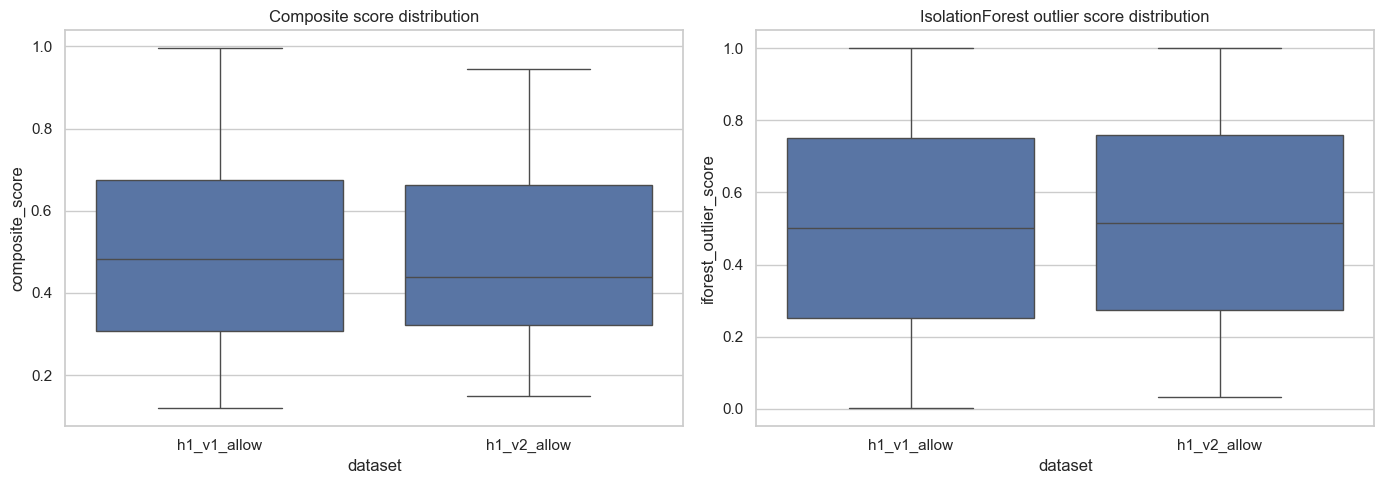

v1 top suspicious


,dataset,trial_id,path,robust_outlier_count,iqr_outlier_count,extreme_1pct_count,iforest_outlier_score,robust_outlier_count_rank,iqr_outlier_count_rank,extreme_1pct_count_rank,composite_score
0,h1_v1_allow,398,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00398.json,10,11,13,1.000000,1.000000,1.000000,0.979861,0.994965
1,h1_v1_allow,163,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00163.json,7,8,14,0.991667,0.996528,0.997222,0.990278,0.993924
2,h1_v1_allow,51,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00051.json,6,6,14,0.994444,0.992361,0.991667,0.990278,0.992188
3,h1_v1_allow,325,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00325.json,6,4,12,0.986111,0.992361,0.956944,0.940278,0.968924
4,h1_v1_allow,399,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00399.json,5,4,12,0.990278,0.981944,0.956944,0.940278,0.967361
5,h1_v1_allow,729,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00729.json,5,5,12,0.965278,0.981944,0.979861,0.940278,0.966840
6,h1_v1_allow,750,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00750.json,3,5,16,0.997222,0.875000,0.979861,1.000000,0.963021
7,h1_v1_allow,720,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00720.json,5,4,14,0.913889,0.981944,0.956944,0.990278,0.960764
8,h1_v1_allow,266,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00266.json,5,3,12,0.969444,0.981944,0.920139,0.940278,0.952951
9,h1_v1_allow,383,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow\trial_00383.json,5,5,11,0.995833,0.981944,0.979861,0.852778,0.952604


v2 top suspicious


,dataset,trial_id,path,robust_outlier_count,iqr_outlier_count,extreme_1pct_count,iforest_outlier_score,robust_outlier_count_rank,iqr_outlier_count_rank,extreme_1pct_count_rank,composite_score
0,h1_v2_allow,704,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00704.json,6,4,20,0.866667,1.000000,0.916667,1.000000,0.945833
1,h1_v2_allow,698,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00698.json,4,4,13,0.800000,0.916667,0.916667,0.750000,0.845833
2,h1_v2_allow,717,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00717.json,2,3,15,0.933333,0.700000,0.800000,0.933333,0.841667
3,h1_v2_allow,707,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00707.json,5,4,14,0.633333,0.966667,0.916667,0.850000,0.841667
4,h1_v2_allow,710,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00710.json,4,3,14,0.733333,0.916667,0.800000,0.850000,0.825000
5,h1_v2_allow,701,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00701.json,3,6,11,1.000000,0.833333,1.000000,0.466667,0.825000
6,h1_v2_allow,713,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00713.json,2,2,15,0.966667,0.700000,0.583333,0.933333,0.795833
7,h1_v2_allow,694,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00694.json,2,2,12,0.766667,0.700000,0.583333,0.600000,0.662500
8,h1_v2_allow,700,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00700.json,2,1,15,0.700000,0.700000,0.316667,0.933333,0.662500
9,h1_v2_allow,697,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00697.json,1,2,13,0.833333,0.466667,0.583333,0.750000,0.658333


In [29]:
v1_analysis_features = [c for c in shared_feature_cols if v1_df[c].notna().sum() > 0]
v2_analysis_features = [c for c in shared_feature_cols if v2_df[c].notna().sum() > 0]

v1_trial_scores = compute_trial_scores(v1_df, v1_analysis_features)
v2_trial_scores = compute_trial_scores(v2_df, v2_analysis_features)

score_summary_df = pd.DataFrame([
    {
        "dataset": "h1_v1_allow",
        "trial_count": len(v1_trial_scores),
        "composite_mean": float(v1_trial_scores["composite_score"].mean()),
        "composite_p95": float(v1_trial_scores["composite_score"].quantile(0.95)),
        "iforest_mean": float(v1_trial_scores["iforest_outlier_score"].mean()),
        "iforest_p95": float(v1_trial_scores["iforest_outlier_score"].quantile(0.95)),
    },
    {
        "dataset": "h1_v2_allow",
        "trial_count": len(v2_trial_scores),
        "composite_mean": float(v2_trial_scores["composite_score"].mean()),
        "composite_p95": float(v2_trial_scores["composite_score"].quantile(0.95)),
        "iforest_mean": float(v2_trial_scores["iforest_outlier_score"].mean()),
        "iforest_p95": float(v2_trial_scores["iforest_outlier_score"].quantile(0.95)),
    },
])

display(score_summary_df)

score_plot_df = pd.concat([
    v1_trial_scores.assign(dataset="h1_v1_allow"),
    v2_trial_scores.assign(dataset="h1_v2_allow"),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=score_plot_df, x="dataset", y="composite_score", ax=axes[0])
axes[0].set_title("Composite score distribution")
sns.boxplot(data=score_plot_df, x="dataset", y="iforest_outlier_score", ax=axes[1])
axes[1].set_title("IsolationForest outlier score distribution")
plt.tight_layout()
plt.show()

print("v1 top suspicious")
display(v1_trial_scores.head(15))
print("v2 top suspicious")
display(v2_trial_scores.head(15))

## 5. 분석 리포트

In [30]:
top_null_gap = compare_quality_df.sort_values("null_ratio_gap", key=lambda s: s.abs(), ascending=False)["feature"].head(10).tolist()
top_shift = shift_df.sort_values("abs_smd", ascending=False)["feature"].head(10).tolist()
top_v2_escape = reference_compare_df.sort_values(["iqr_rate_gap", "extreme_rate_gap"], ascending=False)["feature"].head(10).tolist()
top_v2_reference_trials = reference_trial_df[reference_trial_df["dataset"] == "h1_v2_allow"].sort_values("reference_composite_score", ascending=False)["trial_id"].head(10).tolist()

print("[요약]")
print(f"- v1 trial 수: {len(v1_df)}")
print(f"- v2 trial 수: {len(v2_df)}")
print(f"- 공통 feature 수: {len(shared_feature_cols)}")
print(f"- v1 reference 생성 feature 수: {len(reference_stats_df)}")

print("\n[v1-v2 품질 차이 우선 확인 feature]")
print(top_null_gap)

print("\n[v1-v2 분포 shift 우선 확인 feature]")
print(top_shift)

print("\n[v1 기준선에서 v2가 더 자주 벗어나는 feature]")
print(top_v2_escape)

print("\n[v1 기준으로 먼저 검토할 v2 outlier trial_id]")
print(top_v2_reference_trials)

print("\n[해석 포인트]")
print("1. null_ratio / zero_ratio 차이가 큰 feature는 추출 방식 차이 또는 이벤트 부족 영향 후보")
print("2. abs_smd가 큰 feature는 v1과 v2의 분포가 실질적으로 달라졌다는 뜻")
print("3. v1 기준 경계에서 v2 이탈률이 높은 feature는 학습 전 outlier screening 핵심 후보")
print("4. v2는 표본 수가 30건이므로, 제거 기준은 일괄 삭제보다 상위 suspicious trial 수동 검토가 안전")

[요약]
- v1 trial 수: 720
- v2 trial 수: 30
- 공통 feature 수: 34
- v1 reference 생성 feature 수: 27

[v1-v2 품질 차이 우선 확인 feature]
['click_offset_from_element_center_px', 'time_from_element_clickable_to_click_ms', 'time_from_element_visible_to_click_ms', 'immediate_post_render_click_rate', 'mouse_hover_dwell_time_ms', 'click_offset_variance_px', 'inter_element_move_interval_std_ms', 'click_position_repeat_rate', 'click_sequence_consistency_score', 'mouse_jerk_mean']

[v1-v2 분포 shift 우선 확인 feature]
['click_sequence_consistency_score', 'mouse_overshoot_flag', 'misclick_rate', 'double_click_rate', 'mouse_direction_change_count', 'click_position_repeat_rate', 'pre_click_path_500ms_straightness', 'pre_click_path_500ms_total_distance_px', 'pre_click_path_300ms_total_distance_px', 'mousemove_event_rate']

[v1 기준선에서 v2가 더 자주 벗어나는 feature]
['click_sequence_consistency_score', 'misclick_rate', 'mouse_overshoot_flag', 'pre_click_hover_time_ms', 'mouse_speed_change_mean', 'edge_or_fixed_point_visit_rate', 'm